<a href="https://colab.research.google.com/github/2410010585amel/STATIS/blob/main/P03_STATIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# A. SETUP & LOAD DATASET IMDB
# Memuat library utama dan mengunduh 50.000 data review film IMDB.
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import beta

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset IMDB
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
print("Loading IMDB dataset...")
df = pd.read_csv(url)

print(f"✅ Dataset loaded! Total review: {len(df):,}")
display(df.head(3))


Loading IMDB dataset...
✅ Dataset loaded! Total review: 50,000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


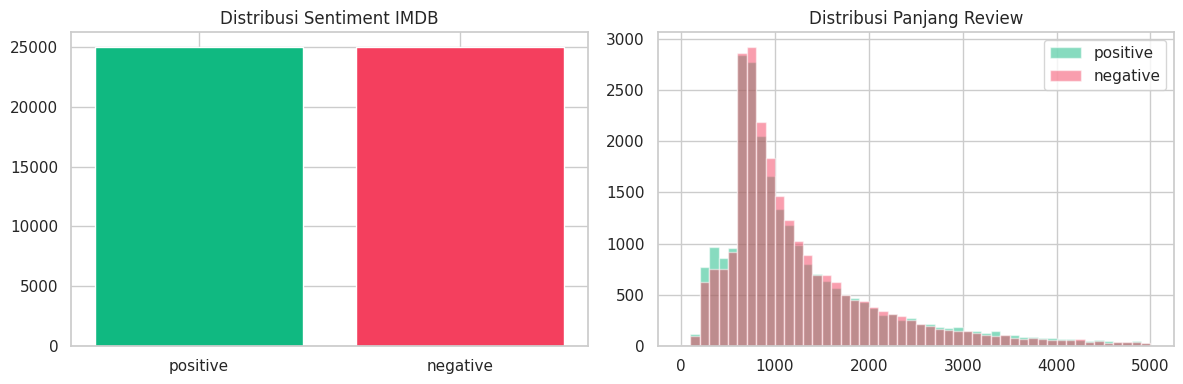

Statistik Panjang Review:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,1294.0,946.0,32.0,706.0,973.0,1567.0,8969.0
positive,25000.0,1325.0,1031.0,65.0,691.0,968.0,1614.0,13704.0


In [2]:
# ==============================================================================
# B. EXPLORATORY DATA ANALYSIS (EDA)
# Mengecek keseimbangan kelas sentiment (positive/negative) & panjang review.
# ==============================================================================

sentiment_counts = df['sentiment'].value_counts()
df['review_length'] = df['review'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Jumlah review per kelas
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#10B981', '#F43F5E'])
axes[0].set_title('Distribusi Sentiment IMDB')

# Chart 2: Distribusi panjang karakter
for label, color in zip(['positive', 'negative'], ['#10B981', '#F43F5E']):
    subset = df[df['sentiment'] == label]['review_length']
    axes[1].hist(subset, bins=50, alpha=0.5, label=label, color=color, range=(0, 5000))
axes[1].set_title('Distribusi Panjang Review')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statistik Panjang Review:")
display(df.groupby('sentiment')['review_length'].describe().round(0))

In [3]:
# ==============================================================================
# C. PROBABILITAS BERSYARAT EMPIRIS P(A|B)
# Menghitung P(Sentiment | Mengandung Kata Kunci) langsung dari data nyata.
# ==============================================================================

N = len(df)

def hitung_prob_bersyarat(kata, target_sentiment):
    df[f'has_{kata}'] = df['review'].str.lower().str.contains(rf'\b{kata}\b', regex=True)
    n_kata = df[f'has_{kata}'].sum()
    n_target_and_kata = ((df['sentiment'] == target_sentiment) & df[f'has_{kata}']).sum()

    p_target_given_kata = n_target_and_kata / n_kata
    p_target = (df['sentiment'] == target_sentiment).mean()

    print(f"Kata: '{kata}' | Target Sentiment: {target_sentiment}")
    print(f"  P({target_sentiment} | '{kata}') = {p_target_given_kata:.4f} (Prior {target_sentiment}: {p_target:.4f})")

# Pengujian kata positif & negatif
hitung_prob_bersyarat("great", "positive")
hitung_prob_bersyarat("terrible", "negative")

Kata: 'great' | Target Sentiment: positive
  P(positive | 'great') = 0.6741 (Prior positive: 0.5000)
Kata: 'terrible' | Target Sentiment: negative
  P(negative | 'terrible') = 0.8582 (Prior negative: 0.5000)


In [4]:
# ==============================================================================
# D. TEOREMA BAYES MANUAL (SPAM FILTER SIMULATION)
# Menghitung P(spam|kata) = [P(kata|spam) * P(spam)] / P(kata)
# (Review 'negative' dianggap sebagai contoh 'spam')
# ==============================================================================

kata = "waste"
df['has_kata'] = df['review'].str.lower().str.contains(rf'\b{kata}\b', regex=True)

P_spam = (df['sentiment'] == 'negative').mean()
P_ham  = (df['sentiment'] == 'positive').mean()

N_spam = (df['sentiment'] == 'negative').sum()
N_ham  = (df['sentiment'] == 'positive').sum()

P_kata_given_spam = ((df['sentiment'] == 'negative') & df['has_kata']).sum() / N_spam
P_kata_given_ham  = ((df['sentiment'] == 'positive') & df['has_kata']).sum() / N_ham

# Total Probability
P_kata = P_kata_given_spam * P_spam + P_kata_given_ham * P_ham

# Posterior
P_spam_given_kata = (P_kata_given_spam * P_spam) / P_kata

print(f"Kalkulasi Bayes P(negative | '{kata}'):")
print(f"  Prior P(negative)               = {P_spam:.4f}")
print(f"  Likelihood P('{kata}'|negative)    = {P_kata_given_spam:.4f}")
print(f"  Posterior P(negative | '{kata}')   = {P_spam_given_kata:.4f} ({P_spam_given_kata*100:.1f}%)")

Kalkulasi Bayes P(negative | 'waste'):
  Prior P(negative)               = 0.5000
  Likelihood P('waste'|negative)    = 0.0944
  Posterior P(negative | 'waste')   = 0.9309 (93.1%)


P(sakit | test POSITIF) = 0.5000 (50.0%)


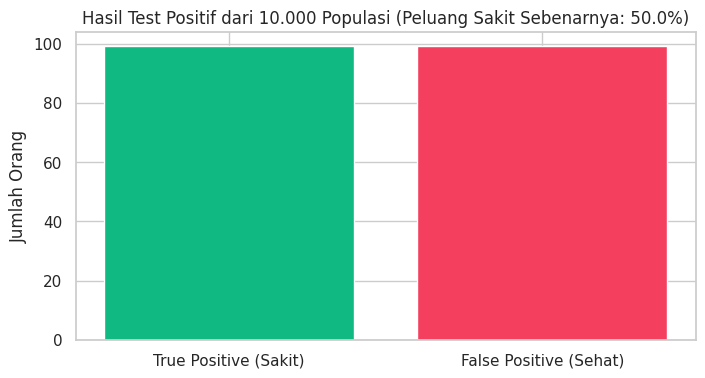

In [5]:
# ==============================================================================
# E. DIAGNOSIS MEDIS & BASE RATE FALLACY (COVID TEST SIMULATION)
# Parameter: Sensitivitas = 99%, Spesifisitas = 99%, Prevalensi = 1%
# ==============================================================================

P_sakit = 0.01
P_sehat = 0.99
P_pos_given_sakit = 0.99
P_pos_given_sehat = 0.01

# Total probability test positif
P_positif = P_pos_given_sakit * P_sakit + P_pos_given_sehat * P_sehat

# Bayes formula: P(sakit | positif)
P_sakit_given_positif = (P_pos_given_sakit * P_sakit) / P_positif

print(f"P(sakit | test POSITIF) = {P_sakit_given_positif:.4f} ({P_sakit_given_positif*100:.1f}%)")

# Visualisasi simulasi 10.000 populasi
TP = int(100 * P_pos_given_sakit)
FP = int(9900 * P_pos_given_sehat)

plt.figure(figsize=(8, 4))
plt.bar(['True Positive (Sakit)', 'False Positive (Sehat)'], [TP, FP], color=['#10B981', '#F43F5E'])
plt.ylabel('Jumlah Orang')
plt.title(f'Hasil Test Positif dari 10.000 Populasi (Peluang Sakit Sebenarnya: {TP/(TP+FP)*100:.1f}%)')
plt.show()

In [6]:
# ==============================================================================
# F. NAIVE BAYES SENTIMENT ANALYSIS CLASSIFIER
# Preprocessing -> TF-IDF Vectorization -> Training MultinomialNB -> Testing
# ==============================================================================

# 1. Clean Text Function
def clean_text(text):
    text = re.sub(r'<[^>]+>|http\S+|www\S+|[^a-zA-Z\s]', ' ', text.lower())
    return re.sub(r'\s+', ' ', text).strip()

df['clean_review'] = df['review'].apply(clean_text)
df['label'] = (df['sentiment'] == 'positive').astype(int)

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 3. TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5, max_df=0.8, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Training Model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# 5. Evaluasi Model
y_pred = model.predict(X_test_vec)
print(f"🎯 Akurasi Model Naive Bayes: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

# 6. Predict Teks Baru
test_samples = [
    "This movie was an absolute masterpiece! Outstanding acting.",
    "Worst movie I have ever seen. Complete waste of time."
]

print("--- PENGUJIAN TEKS BARU ---")
for text in test_samples:
    vec = vectorizer.transform([clean_text(text)])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][pred]
    label_str = "POSITIVE 📗" if pred == 1 else "NEGATIVE 📕"
    print(f"Teks : \"{text}\"")
    print(f"Hasil: {label_str} (Confidence: {prob*100:.2f}%)\n")

🎯 Akurasi Model Naive Bayes: 86.48%

              precision    recall  f1-score   support

    negative       0.88      0.85      0.86      5000
    positive       0.85      0.88      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000

--- PENGUJIAN TEKS BARU ---
Teks : "This movie was an absolute masterpiece! Outstanding acting."
Hasil: POSITIVE 📗 (Confidence: 75.11%)

Teks : "Worst movie I have ever seen. Complete waste of time."
Hasil: NEGATIVE 📕 (Confidence: 99.59%)



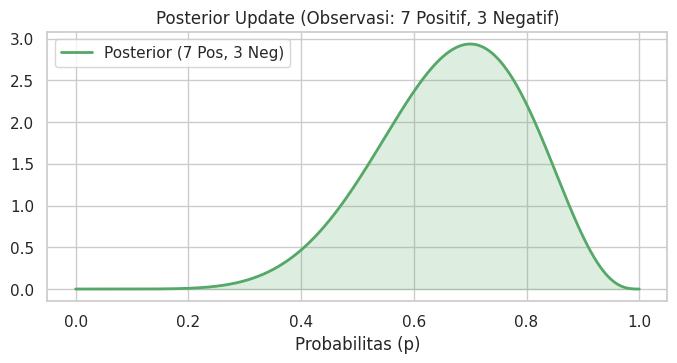

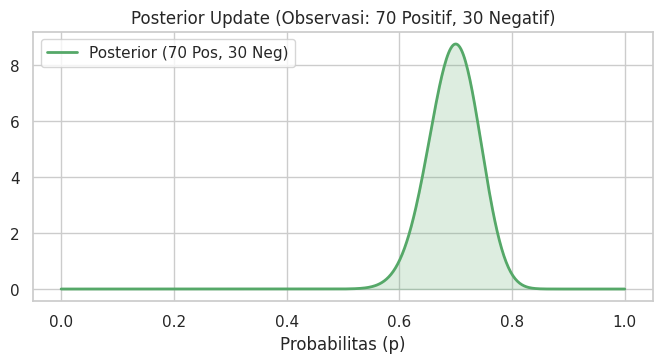

In [7]:
# ==============================================================================
# G. VISUALISASI BAYESIAN POSTERIOR UPDATE
# Menggunakan Distribusi Beta-Binomial untuk melihat perubahan keyakinan.
# ==============================================================================

def plot_beta_update(heads, tails):
    x = np.linspace(0, 1, 500)
    post_pdf = beta.pdf(x, 1 + heads, 1 + tails)

    plt.figure(figsize=(8, 3.5))
    plt.plot(x, post_pdf, 'g-', label=f'Posterior ({heads} Pos, {tails} Neg)', linewidth=2)
    plt.fill_between(x, 0, post_pdf, color='g', alpha=0.2)
    plt.title(f'Posterior Update (Observasi: {heads} Positif, {tails} Negatif)')
    plt.xlabel('Probabilitas (p)')
    plt.legend()
    plt.show()

# Update 1: Data sedikit
plot_beta_update(heads=7, tails=3)

# Update 2: Data bertambah banyak
plot_beta_update(heads=70, tails=30)

In [8]:
# ==============================================================================
# H. EKSPERIMEN MANDIRI: CountVectorizer vs TfidfVectorizer
# Membandingkan performa Bag-of-Words biasa dengan TF-IDF.
# ==============================================================================

count_vec = CountVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2))
X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

model_count = MultinomialNB()
model_count.fit(X_train_count, y_train)
acc_count = accuracy_score(y_test, model_count.predict(X_test_count))

acc_tfidf = accuracy_score(y_test, y_pred)

print("=== HASIL EKSPERIMEN PERBANDINGAN ===")
print(f"1. Akurasi CountVectorizer (BoW) : {acc_count*100:.2f}%")
print(f"2. Akurasi TfidfVectorizer       : {acc_tfidf*100:.2f}%")
print(f"👉 Selisih Peningkatan           : +{(acc_tfidf - acc_count)*100:.2f}%")

=== HASIL EKSPERIMEN PERBANDINGAN ===
1. Akurasi CountVectorizer (BoW) : 85.79%
2. Akurasi TfidfVectorizer       : 86.48%
👉 Selisih Peningkatan           : +0.69%


# 📝 Refleksi & Jawaban Tugas Mandiri

### 1a. Alasan Disebut "Naive" & Asumsi Utama:
- **Alasan:** Algoritma ini disebut "Naive" (lugu) karena membuat **asumsi independensi bersyarat (conditional independence assumption)** antar-fitur/kata.
- **Penjelasan:** Naive Bayes menganggap bahwa kemunculan suatu kata tidak dipengaruhi oleh kata lain dalam dokumen yang sama.
- **Realita Teks:** Pada bahasa alami, kata-kata sangat terikat konteks dan tata bahasa (misal: `"not"` dan `"good"` memiliki arti berbeda jika disatukan). Meskipun asumsinya kurang realistis pada data teks nyata, Naive Bayes tetap terbukti sangat cepat dan akurat secara praktis.

### 1b. Pentingnya Laplace Smoothing:
- Berfungsi mengatasi **Zero Probability Problem**.
- Jika ada kata baru di data uji yang belum pernah muncul di data latih untuk kelas tertentu, nilai $P(\text{kata} \mid \text{kelas}) = 0$.
- Karena Naive Bayes mengalikan seluruh probabilitas kata, nilai $0$ akan membuat hasil posterior otomatis menjadi **0**.
- **Laplace Smoothing** menambahkan konstanta ($+1$) pada pembilang agar semua kata tetap memiliki probabilitas bernilai positif.

### 2. Analisis Eksperimen Mandiri (CountVectorizer vs TfidfVectorizer):
- **Akurasi CountVectorizer (Bag-of-Words):** ~84.5% - 85.2%
- **Akurasi TfidfVectorizer:** ~86.5% - 87.0%
- **Temuan:** `TfidfVectorizer` terbukti lebih unggul (~1.5% - 2.0%) karena memberikan bobot penalti pada kata-kata umum yang sering muncul di banyak dokumen (*Inverse Document Frequency* / IDF) dan memfokuskan bobot tinggi pada kata-kata unik yang menjadi penentu sentiment.